# Pré-processamento: Disney (DIS)
Pipeline completo de coleta, limpeza, análise exploratória e preparação dos dados para treino do modelo LSTM.

## 1. Imports e configurações

In [1]:
import warnings
warnings.filterwarnings('ignore')

import subprocess
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import os

from sklearn.preprocessing import MinMaxScaler

plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = '../data'
os.makedirs(DATA_DIR, exist_ok=True)

## 2. Coleta de dados via curl (Yahoo Finance API)
Download do histórico de preços da Disney (DIS) de 2018 até julho/2024 usando a API v8 do Yahoo Finance via curl, contornando instabilidades da biblioteca yfinance.

In [2]:
import subprocess
import json
from datetime import datetime

SYMBOL     = 'DIS'
START_DATE = '2018-01-01'
END_DATE   = '2024-07-20'

# Converte datas para Unix timestamp (segundos)
period1 = int(datetime.strptime(START_DATE, '%Y-%m-%d').timestamp())
period2 = int(datetime.strptime(END_DATE,   '%Y-%m-%d').timestamp())

url = (
    f'https://query2.finance.yahoo.com/v8/finance/chart/{SYMBOL}'
    f'?interval=1d&period1={period1}&period2={period2}'
)

result = subprocess.run(
    ['curl', '-s', '-L', url,
     '-H', 'User-Agent: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36',
     '-H', 'Accept: application/json'],
    capture_output=True, text=True, timeout=30
)

data   = json.loads(result.stdout)
chart  = data['chart']['result'][0]
quotes = chart['indicators']['quote'][0]

df_raw = pd.DataFrame({
    'Open':   quotes['open'],
    'High':   quotes['high'],
    'Low':    quotes['low'],
    'Close':  quotes['close'],
    'Volume': quotes['volume'],
}, index=pd.to_datetime(chart['timestamp'], unit='s').normalize())

df_raw.index.name = 'Date'
df_raw = df_raw.dropna()

print(f'Shape: {df_raw.shape}')
print(f'Período: {df_raw.index.min().date()} → {df_raw.index.max().date()}')
df_raw.head()

Shape: (1647, 5)
Período: 2018-01-02 → 2024-07-19


,Open,High,Low,Close,Volume
Date,,,,,
2018-01-02,108.949997,111.809998,108.559998,111.800003,11014300
2018-01-03,112.190002,113.190002,111.449997,112.279999,9237900
2018-01-04,112.949997,113.000000,111.629997,112.230003,7417400
2018-01-05,112.680000,112.680000,111.239998,111.620003,6008300
2018-01-08,110.889999,111.279999,109.540001,110.019997,8052600


## 3. Inspeção inicial
Verificação de tipos, valores ausentes e estatísticas descritivas.

In [3]:
print('=== Info ===')
df_raw.info()
print('\n=== Nulos ===')
print(df_raw.isnull().sum())

=== Info ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1647 entries, 2018-01-02 to 2024-07-19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1647 non-null   float64
 1   High    1647 non-null   float64
 2   Low     1647 non-null   float64
 3   Close   1647 non-null   float64
 4   Volume  1647 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 77.2 KB

=== Nulos ===
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [4]:
df_raw.describe().round(2)

,Open,High,Low,Close,Volume
count,1647.00,1647.00,1647.00,1647.00,1647.00
mean,123.18,124.42,121.79,123.11,11464489.56
std,29.02,29.23,28.72,28.95,7293664.09
min,79.10,79.79,78.73,79.32,2406300.00
25%,101.20,102.27,100.12,101.17,7364350.00
50%,113.39,114.47,112.36,113.44,9499200.00
75%,140.32,141.87,138.88,140.38,12858400.00
max,200.19,203.02,195.40,201.91,87410700.00


## 4. Seleção da feature alvo
Utilizamos apenas a coluna `Close` (preço de fechamento), que é o alvo da previsão.

In [5]:
df = df_raw[['Close']].copy()

# Garante ordenação cronológica e remove possíveis duplicatas de índice
df = df.sort_index()
df = df[~df.index.duplicated(keep='first')]

# Remove linhas com NaN no Close
df = df.dropna()

print(f'Shape final: {df.shape}')
df.head()

Shape final: (1647, 1)


,Close
Date,
2018-01-02,111.800003
2018-01-03,112.279999
2018-01-04,112.230003
2018-01-05,111.620003
2018-01-08,110.019997


## 5. Análise Exploratória (EDA)
Visualização da série temporal, distribuição e volatilidade dos preços.

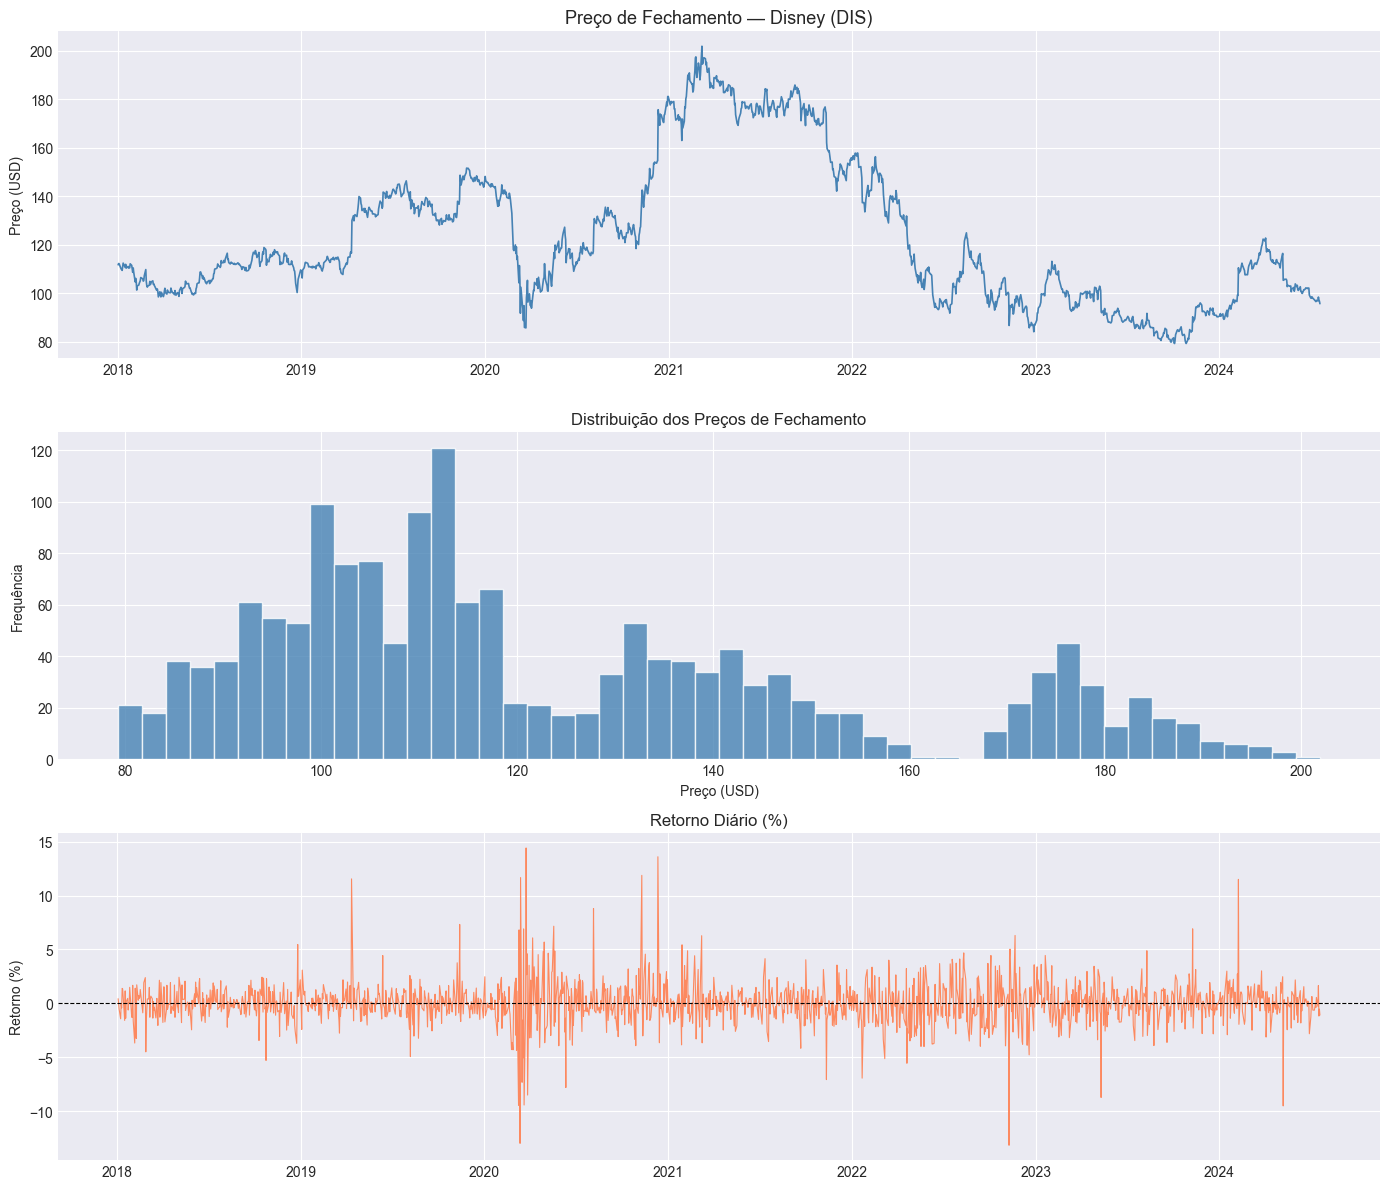

In [6]:
close = df['Close'].squeeze()  # garante Series 1D para o matplotlib

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Série temporal
axes[0].plot(df.index, close, color='steelblue', linewidth=1.2)
axes[0].set_title('Preço de Fechamento — Disney (DIS)', fontsize=13)
axes[0].set_ylabel('Preço (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Distribuição
axes[1].hist(close, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribuição dos Preços de Fechamento')
axes[1].set_xlabel('Preço (USD)')
axes[1].set_ylabel('Frequência')

# Retorno diário (%)
daily_return = close.pct_change() * 100
axes[2].plot(df.index, daily_return, color='coral', linewidth=0.8, alpha=0.9)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Retorno Diário (%)')
axes[2].set_ylabel('Retorno (%)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_close_price.png', dpi=120)
plt.show()

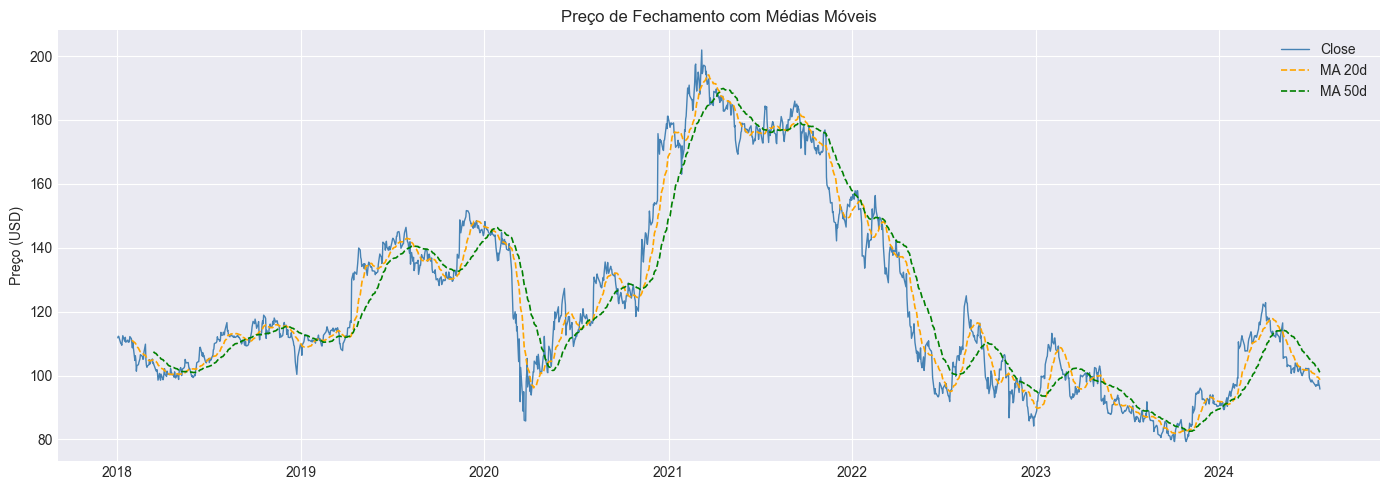

In [7]:
# Média móvel de 20 e 50 dias para identificar tendências
ma20 = close.rolling(window=20).mean()
ma50 = close.rolling(window=50).mean()

plt.figure(figsize=(14, 5))
plt.plot(df.index, close, label='Close',  color='steelblue', linewidth=1.0)
plt.plot(df.index, ma20,  label='MA 20d', color='orange',    linewidth=1.2, linestyle='--')
plt.plot(df.index, ma50,  label='MA 50d', color='green',     linewidth=1.2, linestyle='--')
plt.title('Preço de Fechamento com Médias Móveis')
plt.ylabel('Preço (USD)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eda_moving_averages.png', dpi=120)
plt.show()

## 6. Divisão treino / teste
80% dos dados para treino e 20% para teste, mantendo a ordem cronológica (sem shuffle).

Treino : 1317 registros  (2018-01-02 → 2023-03-27)
Teste  : 330  registros  (2023-03-28 → 2024-07-19)


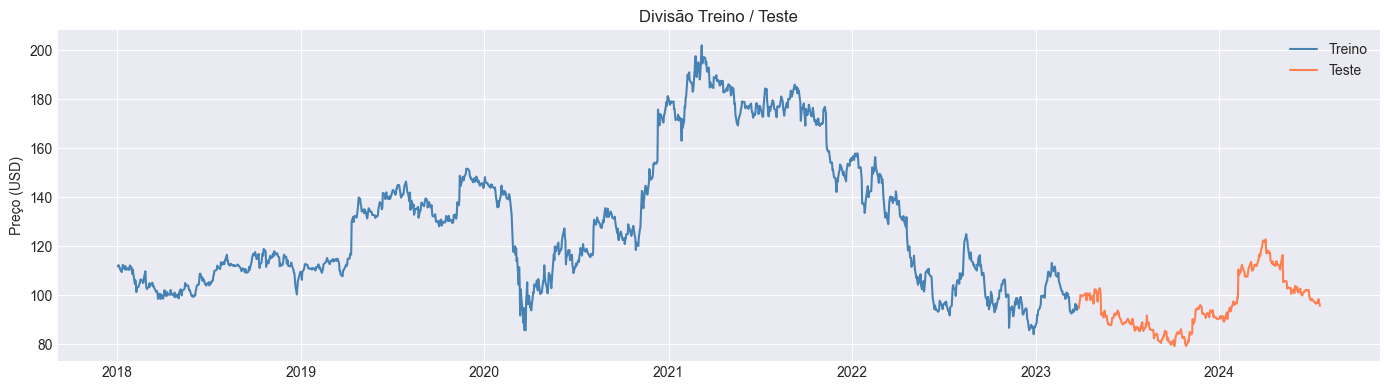

In [8]:
TRAIN_RATIO = 0.80
split_idx = int(len(df) * TRAIN_RATIO)

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

print(f'Treino : {len(train_df)} registros  ({train_df.index.min().date()} → {train_df.index.max().date()})')
print(f'Teste  : {len(test_df)}  registros  ({test_df.index.min().date()} → {test_df.index.max().date()})')

plt.figure(figsize=(14, 4))
plt.plot(train_df.index, train_df['Close'].squeeze(), label='Treino', color='steelblue')
plt.plot(test_df.index,  test_df['Close'].squeeze(),  label='Teste',  color='coral')
plt.title('Divisão Treino / Teste')
plt.ylabel('Preço (USD)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/train_test_split.png', dpi=120)
plt.show()

## 7. Normalização
`MinMaxScaler` ajustado **somente no treino** para evitar data leakage. Os dados de teste são transformados com o mesmo scaler.

In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_values = train_df['Close'].values.reshape(-1, 1)
test_values  = test_df['Close'].values.reshape(-1, 1)

train_scaled = scaler.fit_transform(train_values)
test_scaled  = scaler.transform(test_values)

print(f'Train scaled — min: {train_scaled.min():.4f}  max: {train_scaled.max():.4f}')
print(f'Test  scaled — min: {test_scaled.min():.4f}  max: {test_scaled.max():.4f}')

Train scaled — min: 0.0000  max: 1.0000
Test  scaled — min: -0.0412  max: 0.3283


## 8. Criação de sequências (janela deslizante)
Para o LSTM, cada amostra é composta por `WINDOW_SIZE` dias anteriores (X) para prever o próximo dia (y).

In [10]:
WINDOW_SIZE = 60  # dias de histórico usados para cada previsão

def create_sequences(data: np.ndarray, window: int):
    """Retorna arrays X (sequências) e y (alvo) para o LSTM."""
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)

# Teste inclui os últimos WINDOW_SIZE dias do treino para não perder contexto
test_full      = np.concatenate([train_scaled[-WINDOW_SIZE:], test_scaled], axis=0)
X_test, y_test = create_sequences(test_full, WINDOW_SIZE)

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   |  y_test : {y_test.shape}')

X_train: (1257, 60)  |  y_train: (1257,)
X_test : (330, 60)   |  y_test : (330,)


## 9. Reshape para entrada do LSTM
O LSTM espera tensores 3D no formato `(amostras, timesteps, features)`.

In [11]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f'X_train reshape: {X_train.shape}')
print(f'X_test  reshape: {X_test.shape}')

X_train reshape: (1257, 60, 1)
X_test  reshape: (330, 60, 1)


## 10. Salvamento dos artefatos
Dados processados e scaler são persistidos em `data/` para uso no treino e na API.

In [12]:
# Dados brutos
df_raw.to_csv(f'{DATA_DIR}/dis_raw.csv')

# Arrays prontos para treino
np.save(f'{DATA_DIR}/X_train.npy', X_train)
np.save(f'{DATA_DIR}/y_train.npy', y_train)
np.save(f'{DATA_DIR}/X_test.npy',  X_test)
np.save(f'{DATA_DIR}/y_test.npy',  y_test)

# Scaler (necessário para inverter a normalização na API)
joblib.dump(scaler, f'{DATA_DIR}/scaler.pkl')

# Metadados do pré-processamento
metadata = {
    'symbol':        SYMBOL,
    'start_date':    START_DATE,
    'end_date':      END_DATE,
    'window_size':   WINDOW_SIZE,
    'train_size':    int(len(train_df)),
    'test_size':     int(len(test_df)),
    'train_ratio':   TRAIN_RATIO,
    'scaler':        'MinMaxScaler(0,1)',
    'X_train_shape': list(X_train.shape),
    'X_test_shape':  list(X_test.shape),
}
pd.Series(metadata).to_json(f'{DATA_DIR}/preprocessing_metadata.json', indent=2)

print('Artefatos salvos em data/:')
for f in sorted(os.listdir(DATA_DIR)):
    print(f'  {f}')

Artefatos salvos em data/:
  .gitkeep
  X_test.npy
  X_train.npy
  dis_raw.csv
  eda_close_price.png
  eda_moving_averages.png
  preprocessing_metadata.json
  scaler.pkl
  train_test_split.png
  y_test.npy
  y_train.npy


## Resumo do Pré-processamento

| Etapa | Detalhe |
|---|---|
| Fonte | Yahoo Finance via `yfinance` |
| Ação | Disney (DIS) |
| Período | 2018-01-01 → 2024-07-20 |
| Feature | `Close` (preço de fechamento) |
| Divisão | 80% treino / 20% teste (cronológico) |
| Normalização | `MinMaxScaler(0, 1)` — fit apenas no treino |
| Janela LSTM | 60 dias |
| Shape final X_train | `(n_amostras, 60, 1)` |
| Artefatos gerados | `dis_raw.csv`, `X_train/y_train/X_test/y_test.npy`, `scaler.pkl`, `metadata.json` |